## EDA (Exploratory data analysis)
### 1. Dataset overview 
Goal: understand the size of the dataset and preview the data

The dataset contains 1025 rows and 14 columns.
A preview if the data shows clinical and demographic variables that will be used to predict heart disease outcomes.

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
from src.data.load_data import load_data

#Load data
df = load_data("../data/heart.csv")

In [4]:
df.shape

(1025, 14)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
423,58,0,1,136,319,1,0,152,0,0.0,2,2,2,0
254,35,1,0,120,198,0,1,130,1,1.6,1,0,3,0
884,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
986,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
403,46,0,1,105,204,0,1,172,0,0.0,2,0,2,1


### 2. Data types and quality
Goal: check column types, duplicates and general structure

The dataset consists mainly of numerical variables, with some categorical/bonary features.
There were 723 duplicated rows identified and removed to improve data quality, so the dataset actually contains 302 rows.

In [7]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(302, 14)

### 3. Missing and invalid values
Goal: check null values and medically implausible zeros.

No missing values were detected using "isnull()".
Additionally, an inspection of key physionlogical variables ("trestbps", "chol", "thalach") showed that there are no zero values that would indicate invalid or missing data.

In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
invalid_zero_columns = ["trestbps", "chol", "thalach"]
df[invalid_zero_columns].eq(0).sum()

trestbps    0
chol        0
thalach     0
dtype: int64

### 4. Target distribution
Goal: understand class balance.

The target variable is relatively balanced, with approximately 45.7% if patients without a disease and 54.3% with heart disease.
This balanced distribution reduces the risk of bias toward a single class and allows the use of standard evaluation metrics without requiring special handling for class imbalance.

In [14]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [15]:
df["target"].value_counts(normalize=True)

target
1    0.543046
0    0.456954
Name: proportion, dtype: float64

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/375777618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette='Set2')


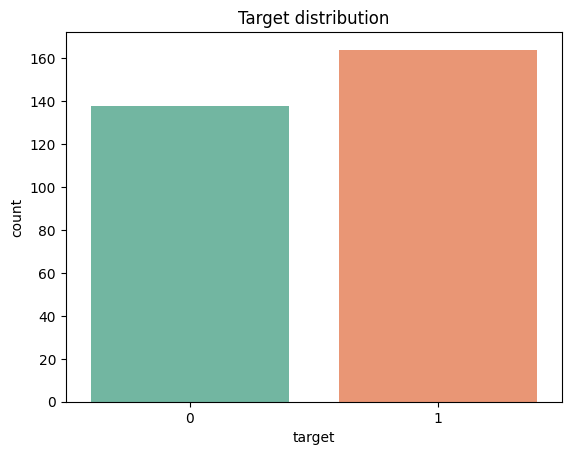

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df, palette='Set2')
plt.title("Target distribution")
plt.show()

### 5. Feature distribution
Goal: understand how individual feature behave.

The distribution of continuous features reveal a mix of approximately normal distribution and skewed patterns.
Features such as age and thalach appear relatively symmetric and well-distributed, suggesting stable variability across the dataset. In contrast, features like oldpeak and chol exibit left-skewed distributions, with a concentration of lower values and a long tail of higher observations.

The distribution of categorical features reveal a mix of binary imbalance and multi-class imbalance.
Features such as sex and exang show moderate imbalance, with a higher proportion of one category compared to the other, Similarly, fb is heavily skewed toward the non-elevated category, indicating that most patients do not exhibit greater than 120 mg/dl.

Multi-class features like cp, slope, ca, and thal display uneven distributions across categories. In particular, some cateogries (e.g. higher values of ca or less frequent thal categories) are relatively underrepresented.

This imbalance my influence the model learning by biasing predictions towards more frequent categories. 

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3430988610.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette='Set2')


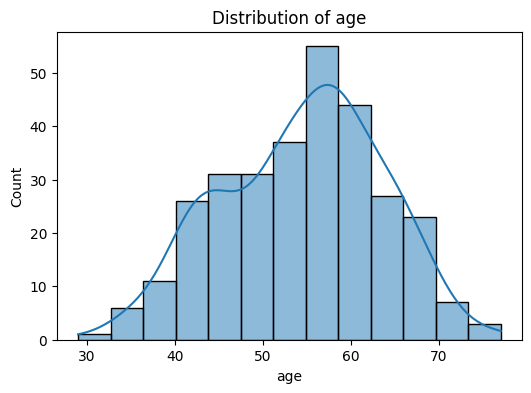

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3430988610.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette='Set2')


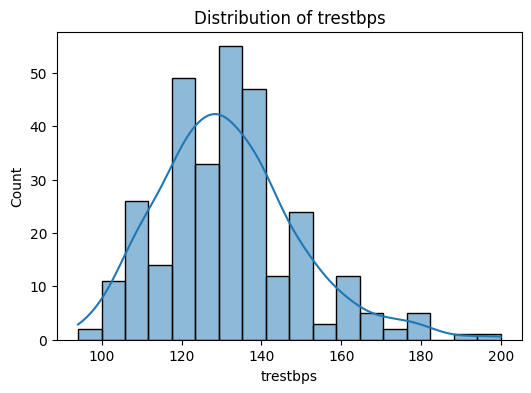

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3430988610.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette='Set2')


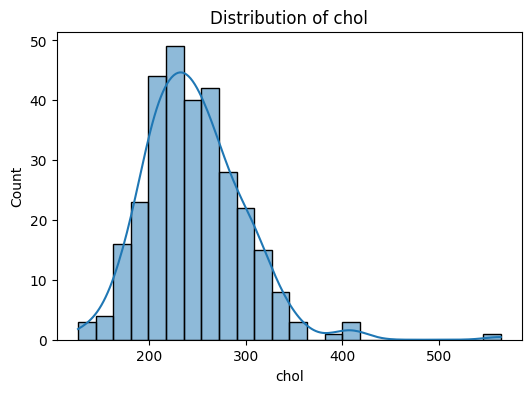

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3430988610.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette='Set2')


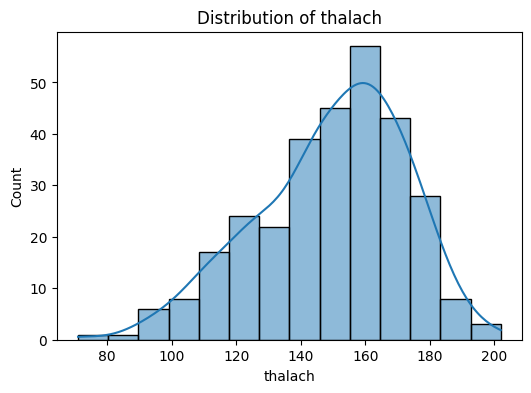

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3430988610.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[feature], kde=True, palette='Set2')


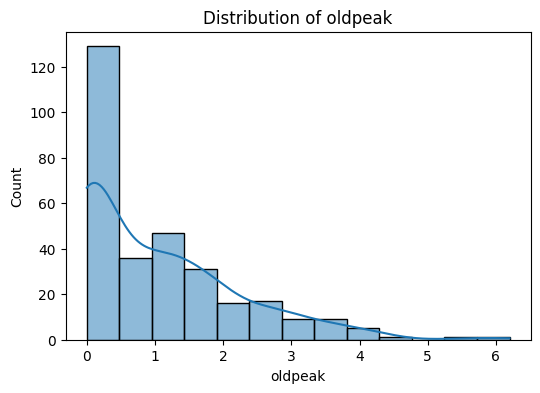

In [17]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True, palette='Set2')
    plt.title(f"Distribution of {feature}")
    plt.show()

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


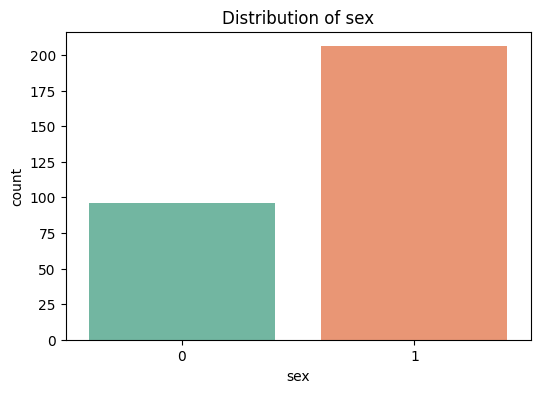

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


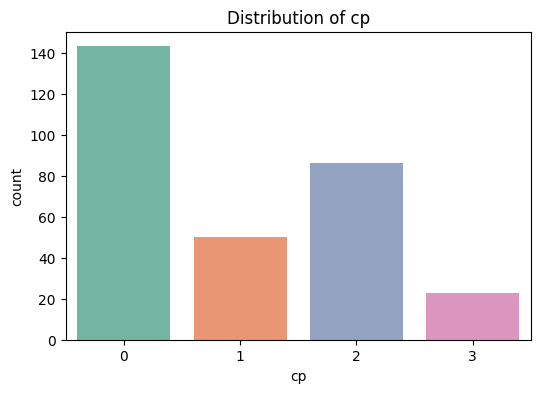

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


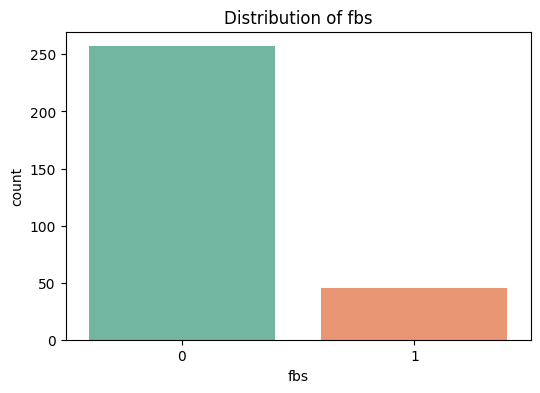

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


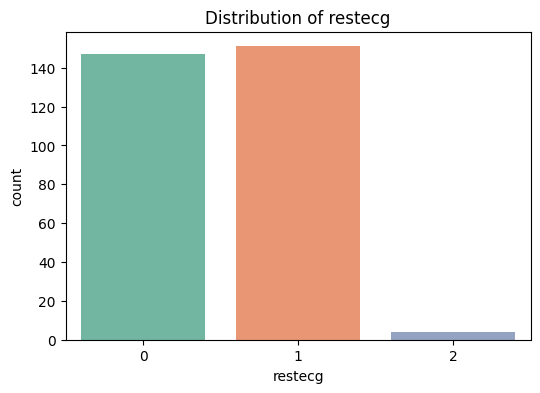

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


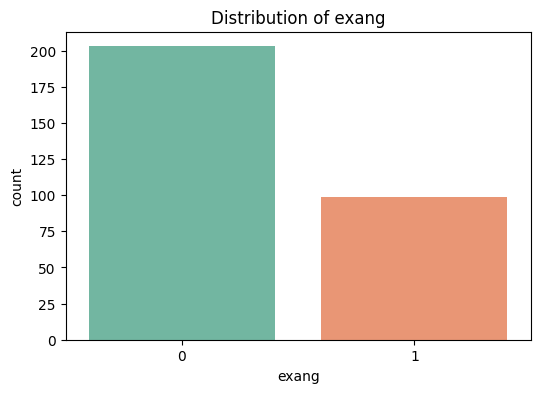

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


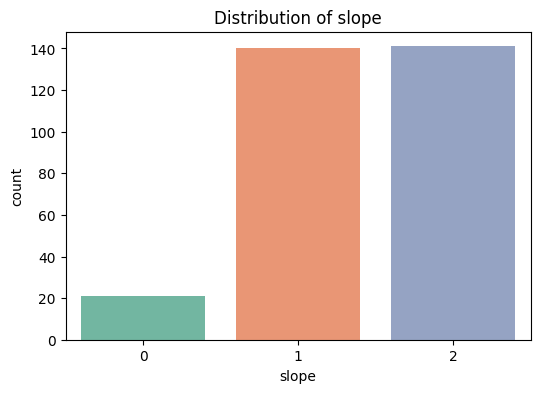

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


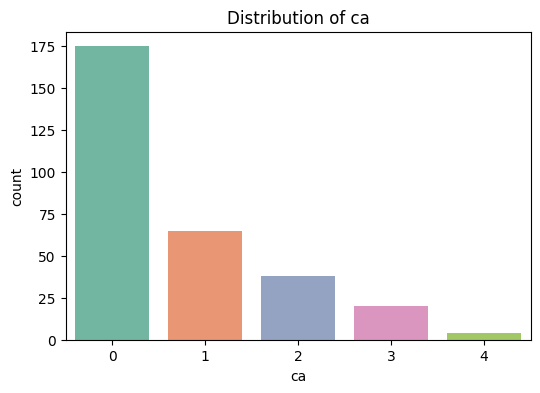

/var/folders/ry/738q370x3tz4mxr4hjvzhsvw0000gn/T/ipykernel_30297/3299604519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='Set2')


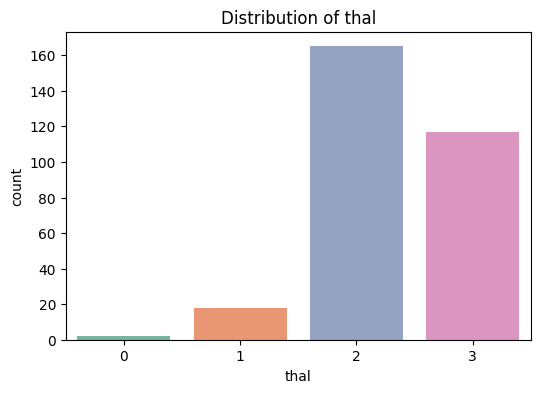

In [19]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=feature, data=df, palette='Set2')
    plt.title(f"Distribution of {feature}")
    plt.show()

### 6. Feature vs target analysis
Goal: see how each features relates to the target.

The distribution of continuous features with respect to the target variable indicates that oldpeak and thalach exhibit more distinct class separation, suggesting a stronger relationship with disease presence.

Specifically, thalach shows an upward shift in its distribution for the disease group, indicating that individuals with the disease tend to have higher maximum thalach rates compared to those without disease. In contrast, oldpeak demonstrates a downward shift, suggesting that diseased patients tend to have lower values relative to the non-disease group. Additionally, a few low-value outliers are observed among diseased patients in thalach, while high-value outliers are present in oldpeak for the same group.

On the other hand, features such as age, trestbps, and chol show minimal median separation and substantial overlap between classes. This indicates that these features have limited discriminative power when considered individually for predicting the target variable.

The distribution of categorical features with respect to the target variable suggests a higher proportion of male patients compared to female patients in the dataset.

For the chest pain type (cp) attribute, non-anginal pain is associated with a higher incidence of disease.
Additionally, patients with fasting blood sugar (fbs) < 120 mg/dL (value = 0) represent the majority of observations, including a larger share of the positive disease class.

The analysis of categorical features reveals several associations with the presence of disease. Patients with exercise-induced angina absent (exang = 0) show a higher proportion of disease cases.

The downsloping ST segment (slope) is strongly associated with a greater incidence of disease.
In the thalassemia (thal) feature, the reversible defect category corresponds to a higher prevalence of disease.
Additionally, patients with no major vessels (ca = 0) represent a larger share of the disease class.

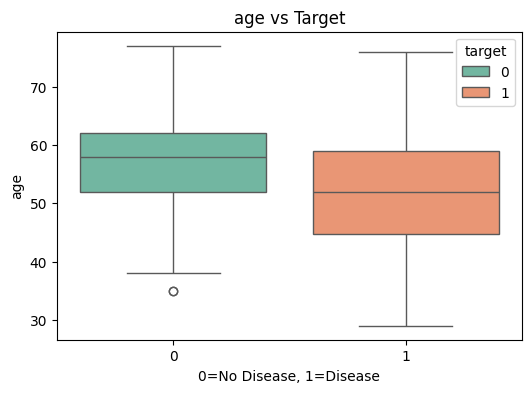

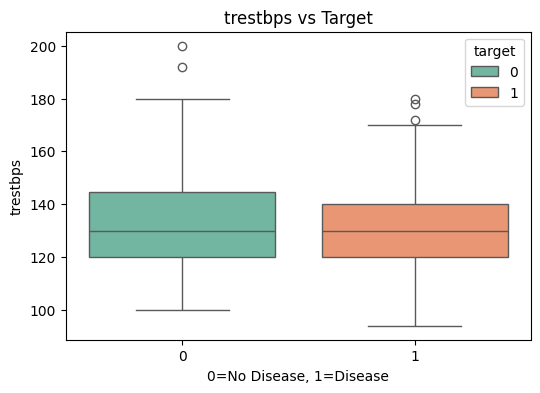

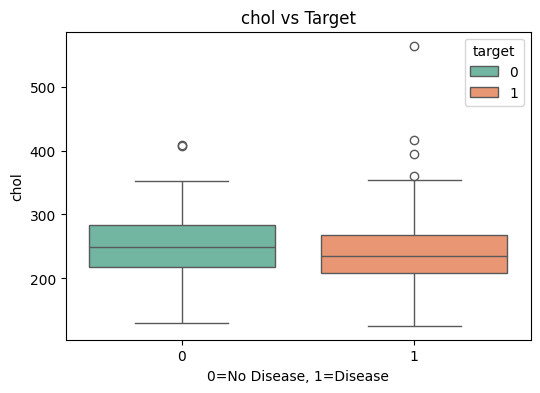

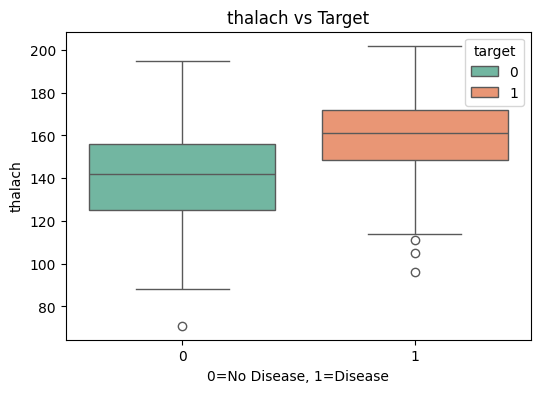

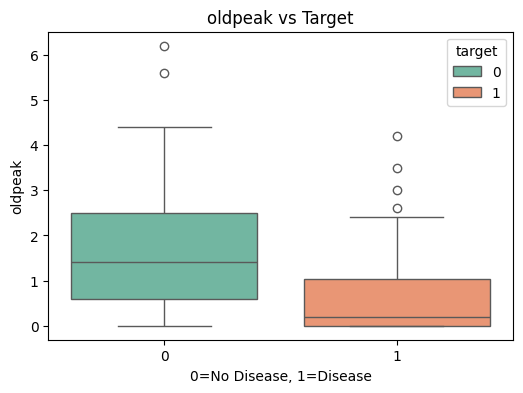

In [20]:
for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=feature, data=df, hue='target', palette='Set2')
    plt.title(f"{feature} vs Target")
    plt.xlabel("0=No Disease, 1=Disease")
    plt.show()

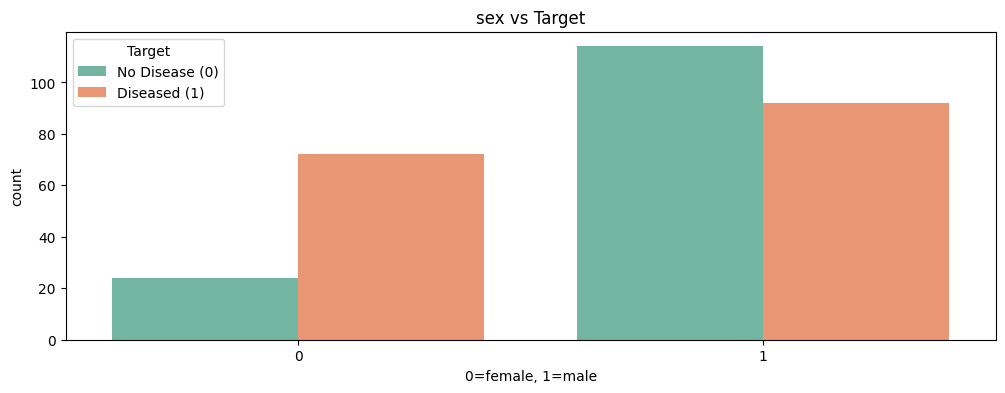

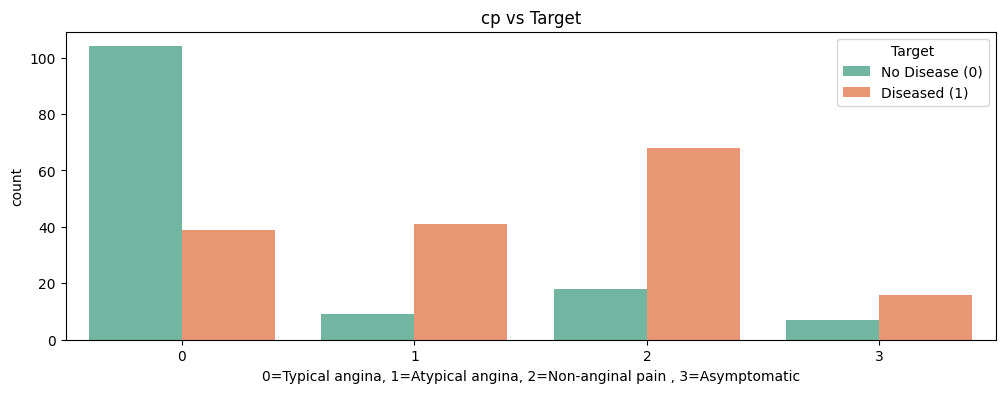

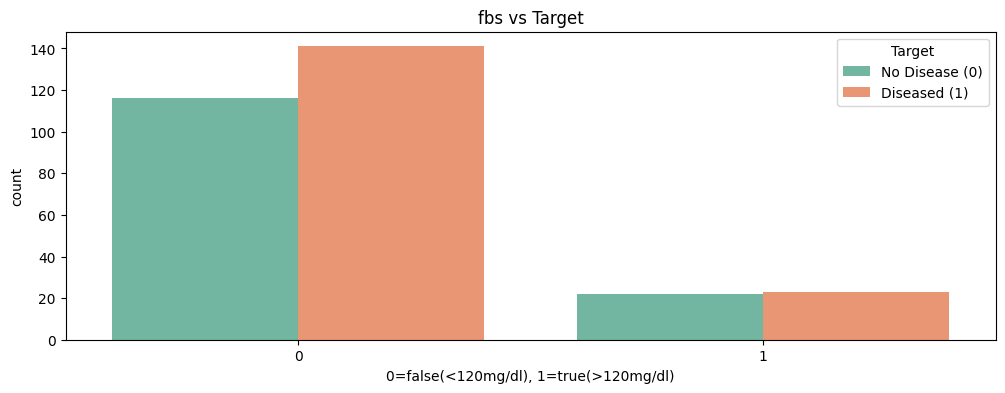

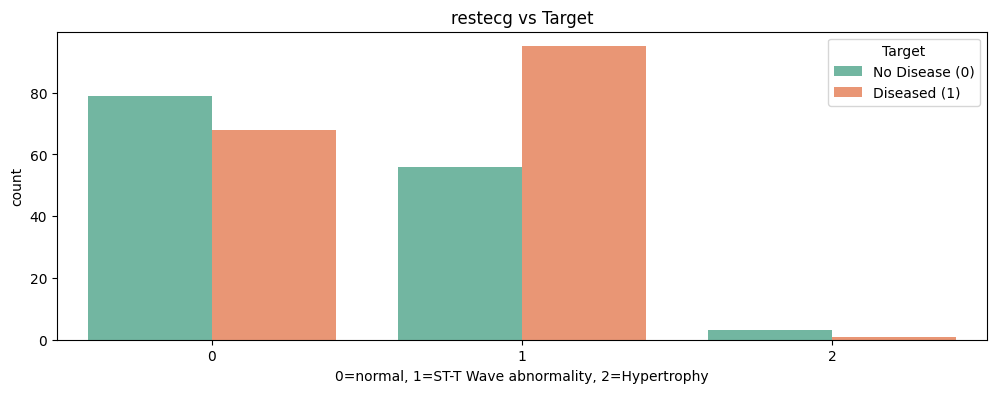

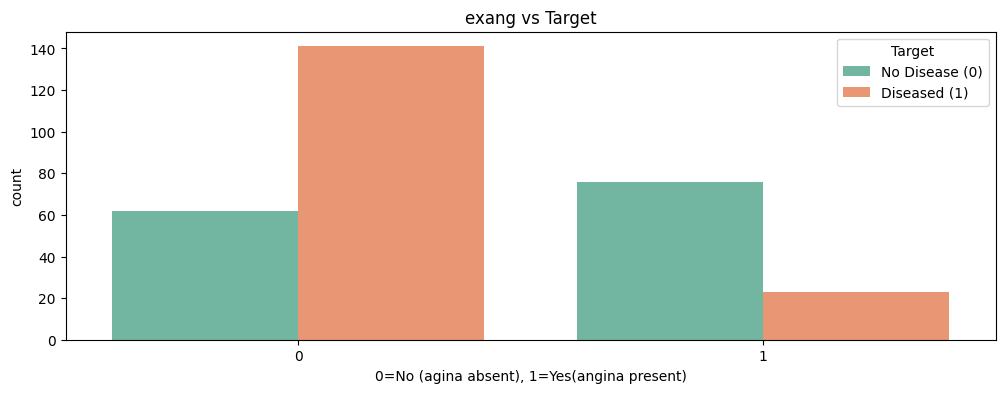

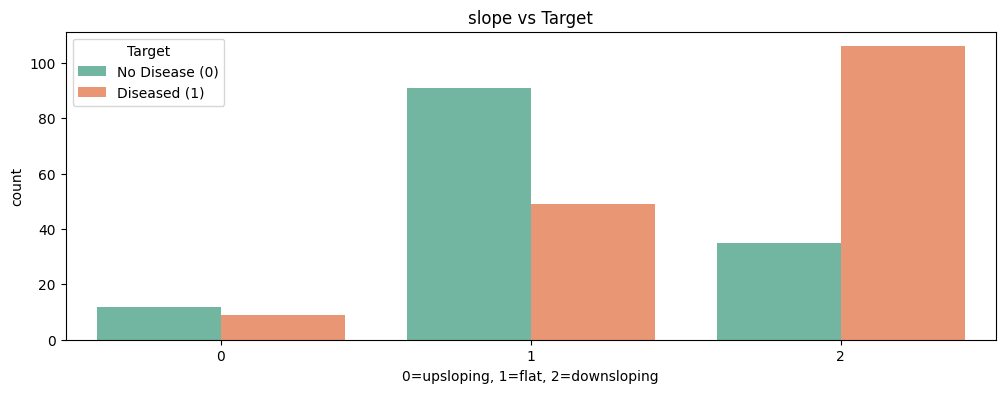

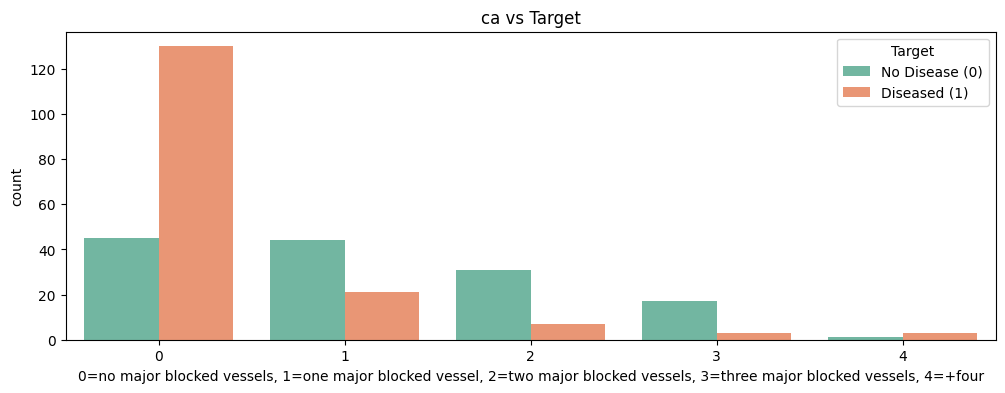

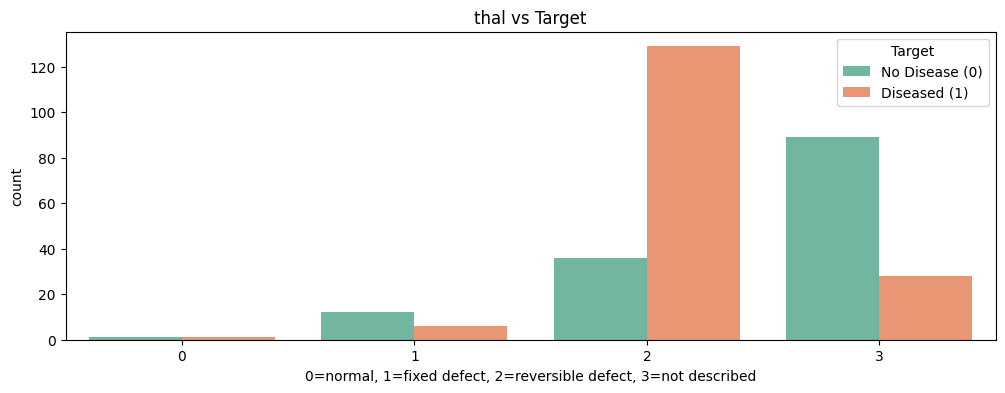

In [21]:
labels = {
    "sex":"0=female, 1=male", 
    "cp":"0=Typical angina, 1=Atypical angina, 2=Non-anginal pain , 3=Asymptomatic", 
    "fbs": "0=false(<120mg/dl), 1=true(>120mg/dl)", 
    "restecg":"0=normal, 1=ST-T Wave abnormality, 2=Hypertrophy", 
    "exang":"0=No (agina absent), 1=Yes(angina present)", 
    "slope":"0=upsloping, 1=flat, 2=downsloping", 
    "ca":"0=no major blocked vessels, 1=one major blocked vessel, 2=two major blocked vessels, 3=three major blocked vessels, 4=+four",
    "thal":"0=normal, 1=fixed defect, 2=reversible defect, 3=not described"}

for feature in categorical_features:
    plt.figure(figsize=(12, 4))
    ax = sns.countplot(x=feature, hue="target", data=df, palette='Set2')
    plt.title(f"{feature} vs Target")
    plt.xlabel(labels.get(feature, feature))
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ["No Disease (0)", "Diseased (1)"], title="Target")
    plt.show()

### 7. Correlation analysis
Goal: understand linear relationship between variables.

the correlation matrix is used to examine the relationship between the atributes and the target.
Features such as cp (chest pain type) and thalach (maximum heart rate achieved) show a strong positive correlation with the target variable, indicating that higher values are associated with an increased likelihood of disease.
In contrast, exang (exercise-induced angina) and oldpeak (ST depression) exhibit a strong negative correlation with the target, suggesting that higher values are associated with a lower likelihood of disease.

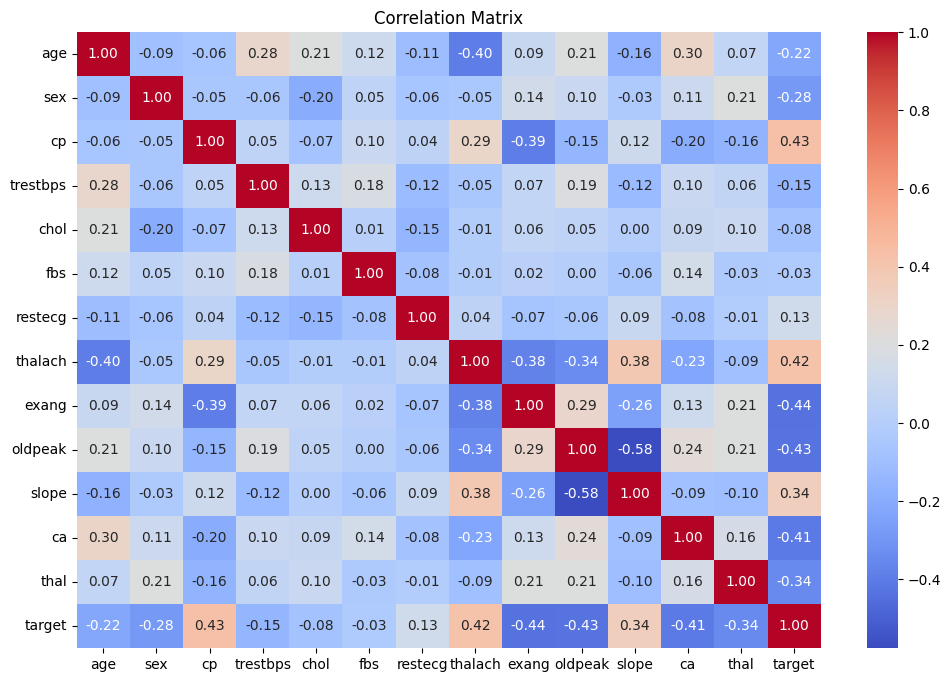

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### 8. Outlier analysis
Goal: identify potential extreme values.

otliers were detected using IQR method.
Fearures such as 'trestbps' and 'chol' and oldpeak show 5 to 9 oulier values.

In [36]:
#using Interquartile Range (QR)
#QR 50% safe zone, 1.5QR tolerance margin, out of these margin: suspicious but not bad 
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        print(IQR)

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
       
        outlier_summary[col] = len(outliers)

    return outlier_summary

In [37]:
outlier_summary = detect_outliers_iqr(df, continuous_features)
outlier_summary

13.0
20.0
63.75
32.75
1.6


{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}